# Lending Club — Analyse Exploratoire des Données
## Prédiction du défaut de paiement

> **Objectif** : Explorer le dataset Lending Club (prêts 2007–2014), comprendre les caractéristiques des emprunteurs, détecter les variables liées au défaut de paiement et préparer les données pour la modélisation.

> **Méthode** : Approche CRISP-DM — Compréhension des données → Préparation → Modélisation

---

## 0. Imports et configuration

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats as sp_stats
import warnings
warnings.filterwarnings('ignore')

# Configuration graphique simplifiée
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'axes.titleweight': 'bold'})

BLUE = '#2166AC'
RED  = '#D6604D'
GRAY = '#636363'


---
## 1. Chargement des données

On télécharge le dataset Lending Club via l'API Kaggle. Il contient l'ensemble des prêts accordés entre 2007 et 2018 avec plus de **150 variables**.

In [4]:
path = kagglehub.dataset_download("wordsforthewise/lending-club")
print(f"Chemin : {path}")

data = pd.read_csv(f"{path}/accepted_2007_to_2018Q4.csv.gz", low_memory=False)
print(f"Dimensions brutes : {data.shape[0]:,} lignes x {data.shape[1]} colonnes")

Chemin : C:\Users\User\.cache\kagglehub\datasets\wordsforthewise\lending-club\versions\3
Dimensions brutes : 2,260,701 lignes x 151 colonnes


In [5]:
# Apercu general du dataset
print(f"Types de données :")
print(data.dtypes.value_counts())
print(f"\nNombre de colonnes numeriques  : {data.select_dtypes(include=['int64','float64']).shape[1]}")
print(f"Nombre de colonnes textuelles  : {data.select_dtypes(include=['object']).shape[1]}")

Types de données :
float64    113
str         38
Name: count, dtype: int64

Nombre de colonnes numeriques  : 113
Nombre de colonnes textuelles  : 38


---
## 2. Filtrage temporel : 2007–2014

On restreint l'analyse aux prêts émis entre **2007 et 2014**.

Ce choix garantit que les prêts ont eu suffisamment de temps pour se dénouer (remboursés ou en défaut) et évite le **biais de survie** — un prêt émis en 2017 n'a pas eu le temps de faire défaut et apparaîtrait artificiellement comme 'Fully Paid'.

In [6]:
data["issue_d"]    = pd.to_datetime(data["issue_d"], format="%b-%Y")
data["issue_year"] = data["issue_d"].dt.year

data = data[(data['issue_year'] >= 2007) & (data['issue_year'] <= 2014)].copy()

print(f"Prets conserves (2007-2014) : {len(data):,}")
print("\nDistribution par annee :")
print(data['issue_year'].value_counts().sort_index().to_string())

Prets conserves (2007-2014) : 466,345

Distribution par annee :
issue_year
2007.0       603
2008.0      2393
2009.0      5281
2010.0     12537
2011.0     21721
2012.0     53367
2013.0    134814
2014.0    235629


---
## 3. Sélection des variables

Dans le cadre de notre analyse de crédit, nous avons sélectionné un ensemble de variables reflétant les informations disponibles au moment de la demande de prêt. Certaines variables, telles que l’historique des comptes ouverts, le nombre total de crédits ou les demandes de crédit récentes, peuvent contenir à la fois des informations antérieures et postérieures au prêt actuel. Par exemple, le nombre de crédits ouverts au cours des 24 derniers mois inclut parfois le prêt pour lequel l’analyse est réalisée. Bien que l’on pourrait techniquement ajuster ces variables pour exclure le prêt courant, nous avons choisi de les conserver telles quelles. Cette décision est motivée par notre objectif principal, qui est d’expliquer le pourcentage de variance des comportements de remboursement à travers les différentes variables. En effet, même si ces variables incluent le prêt actuel, elles restent informatives et pertinentes pour évaluer le profil de risque du demandeur.

In [7]:
variables_avant_pres = [
    # Informations personnelles / socio-économiques
    "annual_inc", "annual_inc_joint", "emp_length", "emp_title",
    "home_ownership", "verification_status", "addr_state",

    # Informations sur la demande de prêt
    "loan_amnt", "term", "purpose", "disbursement_method",

    # Score de crédit
    "fico_range_low", "fico_range_high",

    # Historique du crédit
    "earliest_cr_line", "delinq_2yrs", "mths_since_last_delinq",
    "mths_since_last_record", "pub_rec", "pub_rec_bankruptcies", "tax_liens",

    # Comptes de crédit
    "open_acc", "total_acc", "mort_acc", "num_bc_tl", "num_il_tl",
    "num_rev_accts", "num_op_rev_tl", "num_sats",

    # Comptes ouverts récemment
    "acc_open_past_24mths", "open_acc_6m", "num_tl_op_past_12m",
    "open_il_12m", "open_il_24m", "open_rv_12m", "open_rv_24m",

    # Endettement et utilisation du crédit
    "dti", "dti_joint", "revol_bal", "revol_util", "all_util", "bc_util",
    "bc_open_to_buy", "avg_cur_bal", "max_bal_bc", "total_bal_ex_mort",
    "tot_cur_bal", "tot_hi_cred_lim", "total_bc_limit", "total_rev_hi_lim",
    "total_bal_il", "total_il_high_credit_limit",

    # Incidents de crédit
    "acc_now_delinq", "delinq_amnt", "chargeoff_within_12_mths",
    "collections_12_mths_ex_med", "num_accts_ever_120_pd",
    "num_tl_30dpd", "num_tl_90g_dpd_24m", "num_tl_120dpd_2m",

    # Demandes de crédit
    "inq_fi", "inq_last_6mths", "inq_last_12m", "mths_since_recent_inq",

    # Variables co-emprunteur
    "sec_app_fico_range_low", "sec_app_fico_range_high", "sec_app_earliest_cr_line",
    "sec_app_inq_last_6mths", "sec_app_mort_acc", "sec_app_open_acc",
    "sec_app_revol_util", "sec_app_open_act_il", "sec_app_num_rev_accts",
    "sec_app_chargeoff_within_12_mths", "sec_app_collections_12_mths_ex_med",
    "sec_app_mths_since_last_major_derog", "revol_bal_joint",

    # Variable cible + dates
    "loan_status", "issue_d", "issue_year"
]

# On ne garde que les colonnes qui existent dans le dataset
variables_avant_pres = [v for v in variables_avant_pres if v in data.columns]
data = data[variables_avant_pres].copy()

print(f"Variables selectionnees : {len(variables_avant_pres)}")
print(f"Dimensions : {data.shape[0]:,} x {data.shape[1]}")

Variables selectionnees : 79
Dimensions : 466,345 x 79


---
## 4. Variable cible

La variable cible est `loan_status`. On conserve uniquement deux modalités :
- **Fully Paid (0)** : le prêt a été intégralement remboursé
- **Charged Off (1)** : le prêt est en défaut de paiement

Les prêts encore en cours (`Current`, `Late`...) sont exclus car leur issue est inconnue.

> **Note** : La modalité *'Does not meet the credit policy'* est également exclue car elle correspond à des prêts accordés hors politique de crédit standard — leur comportement peut différer structurellement des prêts standards.

In [ ]:
# Idempotent : loan_status → target (safe si la cellule est ré-exécutée)
if 'loan_status' in data.columns:
    print('Distribution brute de loan_status :')
    print(data['loan_status'].value_counts().to_string())

    target_map = {'Fully Paid': 0, 'Charged Off': 1}
    data = data[data['loan_status'].isin(target_map)].copy()
    data['target'] = data['loan_status'].map(target_map)
    data.drop(columns=['loan_status'], inplace=True)

elif 'target' not in data.columns:
    raise ValueError("Ni 'loan_status' ni 'target' trouvées — vérifier le chargement.")

else:
    print("[INFO] 'target' déjà créée (ré-exécution détectée).")

# Ce bloc s'exécute toujours
n_total   = len(data)
n_default = int(data['target'].sum())
print(f'\nApres filtrage :')
print(f'  Total       : {n_total:,}')
print(f'  Fully Paid  : {n_total-n_default:,}  ({(n_total-n_default)/n_total*100:.1f}%)')
print(f'  Charged Off : {n_default:,}  ({n_default/n_total*100:.1f}%)')


---
## 5. Valeurs manquantes

### 5.1 Visualisation

**Q** : Y a-t-il des valeurs manquantes dans les variables sélectionnées ?

**C** : On calcule le taux de NaN par colonne et on le visualise. On supprime automatiquement les variables dépassant **50%** de valeurs manquantes.

In [ ]:
# Heatmap des valeurs manquantes (echantillon de 3000 lignes pour la lisibilite)
sample = data.sample(min(3000, len(data)), random_state=42)
plt.figure(figsize=(14, 5))
sns.heatmap(sample.isnull(), cbar=False, cmap='Blues', yticklabels=False)
plt.title('Heatmap des valeurs manquantes (echantillon 3 000 lignes)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()


> **Lecture** : Chaque ligne est un prêt, chaque colonne une variable. Une case bleue indique une valeur manquante. On voit clairement les variables avec des NaN concentrés (variables co-emprunteur, certaines variables d'activité récente).

In [ ]:
# Pourcentage de valeurs manquantes par variable
seuil = 50
PROTECTED = ['target', 'issue_d', 'issue_year', 'term']
missing_pct = data.isnull().mean() * 100
cols_drop = [c for c in missing_pct[missing_pct > seuil].index if c not in PROTECTED]

print(f"{len(cols_drop)} variables supprimees (>50% NaN) :")
for c in sorted(cols_drop):
    print(f"  {c:<45} {missing_pct[c]:.1f}%")

data.drop(columns=cols_drop, inplace=True)
print(f"\nDimensions apres suppression : {data.shape[0]:,} x {data.shape[1]}")

27 variables supprimees (>50% NaN) :
  all_util                                      100.0%
  annual_inc_joint                              100.0%
  dti_joint                                     100.0%
  inq_fi                                        100.0%
  inq_last_12m                                  100.0%
  max_bal_bc                                    100.0%
  mths_since_last_delinq                        53.9%
  mths_since_last_record                        86.6%
  open_acc_6m                                   100.0%
  open_il_12m                                   100.0%
  open_il_24m                                   100.0%
  open_rv_12m                                   100.0%
  open_rv_24m                                   100.0%
  revol_bal_joint                               100.0%
  sec_app_chargeoff_within_12_mths              100.0%
  sec_app_collections_12_mths_ex_med            100.0%
  sec_app_earliest_cr_line                      100.0%
  sec_app_fico_range_high     

In [ ]:
# Graphique : taux de valeurs manquantes restantes
missing = (data.isnull().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

bar_colors = [RED if v > 30 else BLUE for v in missing.values]

fig, ax = plt.subplots(figsize=(13, max(5, len(missing)*0.38)))
ax.barh(missing.index[::-1], missing.values[::-1],
        color=bar_colors[::-1], edgecolor='white', height=0.65)
ax.axvline(50, color=RED, linestyle='--', lw=1.5, label='Seuil 50%')
ax.set_xlabel('% valeurs manquantes')
ax.set_title('Taux de valeurs manquantes par variable')
h1 = mpatches.Patch(color=RED,  label='> 30%')
h2 = mpatches.Patch(color=BLUE, label='<= 30%')
ax.legend(handles=[h1, h2, plt.Line2D([0],[0], color=RED, ls='--', label='Seuil 50%')], fontsize=9)
plt.tight_layout()
plt.savefig('01_missing_values.png', bbox_inches='tight')
plt.show()


> **Décision** : Les variables >50% NaN sont supprimées (principalement les variables co-emprunteur, absentes pour les dossiers individuels). Pour les NaN restants, on appliquera une **imputation par la médiane** avant la modélisation.

---
## 6. Doublons

**Q** : Y a-t-il des lignes dupliquées dans le dataset ?

**C** : On vérifie avec `duplicated()` et on supprime les doublons si nécessaire.

In [12]:
n_doublons = data.duplicated().sum()
print(f"Nombre de doublons : {n_doublons}")
if n_doublons > 0:
    data = data.drop_duplicates()
    print(f"Doublons supprimés. Nouvelles dimensions : {data.shape[0]:,} x {data.shape[1]}")
else:
    print("Aucun doublon detecte.")

Nombre de doublons : 0
Aucun doublon detecte.


---
## 7. Traitement des variables catégorielles

Dans cette section, nous analysons et transformons les variables catégorielles pour les rendre exploitables dans les modèles de machine learning.

### 7.1 `emp_title` — Titre du poste

Le titre du poste contient des milliers de valeurs uniques et libres. On les regroupe en **10 catégories métier** homogènes.

In [13]:
def classify_emp_title(title):
    if pd.isna(title): return 'Other'
    t = title.lower()
    if any(x in t for x in ['teacher','rn','registered nurse']): return 'Teacher_Nurse'
    elif any(x in t for x in ['manager','director','supervisor','office manager']): return 'Management'
    elif any(x in t for x in ['us army','usaf','us air force','us navy']): return 'Military'
    elif any(x in t for x in ['usps','united states postal service','ups']): return 'Postal_Delivery'
    elif any(x in t for x in ['bank of america','jp morgan','wells fargo']): return 'Bank_Finance'
    elif 'engineer' in t: return 'Engineer_Tech'
    elif any(x in t for x in ['sales','accountant']): return 'Sales_Accountant'
    elif 'driver' in t: return 'Driver'
    elif 'administrative assistant' in t: return 'Admin_Office'
    else: return 'Other'

if 'emp_title' in data.columns:
    data['emp_title'] = data['emp_title'].apply(classify_emp_title)
    print('Distribution emp_title apres regroupement :')
    print(data['emp_title'].value_counts().to_string())

Distribution emp_title apres regroupement :
emp_title
Other               338205
Management           59120
Teacher_Nurse        24158
Sales_Accountant      9360
Engineer_Tech         8557
Driver                5724
Military              1842
Bank_Finance          1643
Postal_Delivery       1252
Admin_Office          1198


### 7.2 `addr_state` → Régions géographiques

Les 50 états américains sont trop nombreux comme variable catégorielle. On les regroupe en **4 grandes régions** selon la classification du US Census Bureau.

In [14]:
state_region_map = {
    'ME':'Northeast','NH':'Northeast','VT':'Northeast','MA':'Northeast',
    'RI':'Northeast','CT':'Northeast','NY':'Northeast','NJ':'Northeast','PA':'Northeast',
    'OH':'Midwest','IN':'Midwest','IL':'Midwest','MI':'Midwest','WI':'Midwest',
    'MN':'Midwest','IA':'Midwest','MO':'Midwest','ND':'Midwest','SD':'Midwest','NE':'Midwest','KS':'Midwest',
    'DE':'South','MD':'South','DC':'South','VA':'South','WV':'South','NC':'South',
    'SC':'South','GA':'South','FL':'South','KY':'South','TN':'South','MS':'South',
    'AL':'South','OK':'South','TX':'South','AR':'South','LA':'South',
    'ID':'West','MT':'West','WY':'West','NV':'West','UT':'West','CO':'West',
    'AZ':'West','NM':'West','AK':'West','WA':'West','OR':'West','CA':'West','HI':'West'
}

if 'addr_state' in data.columns:
    data['region'] = data['addr_state'].map(state_region_map).fillna('Other')
    print('Distribution region :')
    print(data['region'].value_counts().to_string())

Distribution region :
region
South        156763
West         124092
Northeast     94587
Midwest       75617


### 7.3 `issue_d` + `earliest_cr_line` — Extraction et conversion

On extrait le **mois** et l'**année** d'émission depuis `issue_d`.

On convertit `earliest_cr_line` (date du premier crédit) en **durée d'historique de crédit** (en mois) en calculant l'écart avec `issue_d`. Ces deux opérations doivent être faites **avant** la suppression de `issue_d`.


In [15]:
if 'issue_d' in data.columns:
    # Extraction mois et annee d'emission
    data['issue_month'] = data['issue_d'].dt.month
    data['issue_year']  = data['issue_d'].dt.year
    print('Variables issue_month et issue_year creees.')

    # Conversion earliest_cr_line en duree d'historique de credit
    # Doit etre calcule ICI — avant que issue_d soit supprimee
    if 'earliest_cr_line' in data.columns:
        data['credit_history_months'] = (
            data['issue_d'] - pd.to_datetime(data['earliest_cr_line'], format='%b-%Y')
        ).dt.days / 30
        data.drop(columns=['earliest_cr_line'], inplace=True)
        print(f'credit_history_months cree — mediane : {data["credit_history_months"].median():.0f} mois')

    # Meme traitement pour la co-emprunteuse si presente
    if 'sec_app_earliest_cr_line' in data.columns:
        data['sec_app_credit_history_months'] = (
            data['issue_d'] - pd.to_datetime(data['sec_app_earliest_cr_line'], format='%b-%Y')
        ).dt.days / 30
        data.drop(columns=['sec_app_earliest_cr_line'], inplace=True)
        print('sec_app_credit_history_months cree')

# Suppression des variables textuelles — issue_d en dernier
to_drop = [c for c in ['title','desc','zip_code','application_type',
                        'disbursement_method','issue_d'] if c in data.columns]
data.drop(columns=to_drop, inplace=True)
print(f'Variables supprimees : {to_drop}')
print(f'Dimensions : {data.shape[0]:,} x {data.shape[1]}')


Variables issue_month et issue_year creees.
Variables supprimees : ['disbursement_method', 'issue_d']
Dimensions : 451,059 x 52


### 7.4 `emp_length` — Ancienneté professionnelle

On convertit la variable textuelle en valeur numérique ordinale (0 à 10). Les NaN sont conservés car ils peuvent signifier 'sans emploi'.

In [16]:
if 'emp_length' in data.columns:
    data['emp_length'] = (
        data['emp_length']
        .str.replace(' years','', regex=False)
        .str.replace(' year','', regex=False)
        .str.replace('+','', regex=False)
        .str.replace('< 1','0', regex=False)
    )
    data['emp_length'] = pd.to_numeric(data['emp_length'], errors='coerce')
    print('Distribution emp_length (numerique) :')
    print(data['emp_length'].value_counts().sort_index().to_string())

Distribution emp_length (numerique) :
emp_length
0.0      35010
1.0      28603
2.0      40052
3.0      35463
4.0      27154
5.0      29952
6.0      25402
7.0      25431
8.0      21690
9.0      17256
10.0    144527


### 7.5 Suppression des variables à une seule modalité

Les variables constantes n'apportent aucune information prédictive.

In [17]:
cat_cols = data.select_dtypes(include='object').columns.tolist()
one_modal = [c for c in cat_cols if data[c].nunique() <= 1]
print(f"Variables a une seule modalite : {one_modal}")
if one_modal:
    data.drop(columns=one_modal, inplace=True)
print(f"Dimensions : {data.shape[0]:,} x {data.shape[1]}")

Variables a une seule modalite : []
Dimensions : 451,059 x 52


---
## 8. Analyse univariée

Avant de croiser les variables avec la cible, on explore chaque variable **individuellement** :
distribution, symétrie et valeurs aberrantes.

> **Approche** : Boxplots → Histogrammes + KDE → Skewness → Outliers


### 8.1 Boxplots — toutes les variables numériques

**Q** : Comment se distribue individuellement chaque variable numérique ? Y a-t-il des valeurs aberrantes visibles ?

**C** : Un boxplot par variable (analyse purement univariée — sans split par statut). Cap visuel au 99e percentile. Titre rouge si plus de 5% d'outliers selon la règle IQR.


In [ ]:
# Variables numériques (hors identifiants et cible)
num_cols = [c for c in data.select_dtypes(include=['int64','float64']).columns
            if c not in ['target', 'issue_year', 'issue_month']]

ncols = 4
nrows = -(-len(num_cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    s = data[col].dropna()

    # Détection outliers — règle IQR
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((s < Q1 - 1.5*IQR) | (s > Q3 + 1.5*IQR)).sum()
    pct_out = n_out / len(s) * 100

    # Cap visuel au 99e percentile
    sns.boxplot(y=s[s <= s.quantile(0.99)], ax=ax, color=BLUE,
                flierprops=dict(marker='.', markersize=2, alpha=0.2))

    # Titre rouge si >5% outliers
    title_color = RED if pct_out > 5 else 'black'
    ax.set_title(f'{col}\n({n_out:,} outliers — {pct_out:.1f}%)',
                 fontsize=9, color=title_color)
    ax.set_xlabel('')

# Masquer les axes vides
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Analyse univariée — Boxplots de toutes les variables numériques\n'
             '(cap 99e pct | titre rouge = >5% outliers IQR)', fontsize=14)
plt.tight_layout()
plt.savefig('08_univarie_boxplots.png', bbox_inches='tight')
plt.show()
print(f'Nombre de variables numériques analysées : {len(num_cols)}')


> **Observation** : Plusieurs variables présentent des distributions très étalées — notamment `annual_inc` et `revol_bal` (titres en rouge).
> La médiane permet de comparer rapidement les niveaux centraux entre variables.
> Ces asymétries appellent une analyse de skewness avant de choisir un traitement.


### 8.2 Histogrammes + KDE

**Q** : Quelle est la forme réelle de chaque distribution ? Gaussienne, exponentielle, bimodale ?

**C** : Histogramme avec courbe KDE, médiane (bleu pointillé) et moyenne (rouge pointillé) annotées. Titre rouge si |skew| > 1 (forte asymétrie).


In [ ]:
ncols = 4
nrows = -(-len(num_cols) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    s    = data[col].dropna()
    skw  = round(float(sp_stats.skew(s)), 2)

    # Cap au 99e percentile pour la lisibilité
    s_plot = s[s <= s.quantile(0.99)]

    # Histogramme + KDE
    sns.histplot(s_plot, ax=ax, kde=True, color=BLUE,
                 stat='density', bins=40, alpha=0.55)

    # Lignes médiane / moyenne
    ax.axvline(s.median(), color='navy', ls='--', lw=1.5,
               label=f'Méd. {s.median():,.1f}')
    ax.axvline(s.mean(),   color=RED,   ls=':',  lw=1.5,
               label=f'Moy. {s.mean():,.1f}')

    # Titre rouge si forte asymétrie
    title_color = RED if abs(skw) > 1 else 'black'
    ax.set_title(f'{col}  (skew={skw})', fontsize=9, color=title_color)
    ax.set_ylabel('Densité', fontsize=8)
    ax.legend(fontsize=6.5)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histogrammes + KDE — variables numériques\n'
             '(cap 99e pct | médiane=bleu | moyenne=rouge | titre rouge=|skew|>1)', fontsize=14)
plt.tight_layout()
plt.savefig('09_univarie_histogrammes.png', bbox_inches='tight')
plt.show()


> **Observation** : Un écart visible entre médiane et moyenne révèle une asymétrie (la moyenne est tirée par les valeurs extrêmes).
> Les distributions à titre rouge (|skewness| > 1) sont candidates à une transformation `log1p`
> pour les modèles sensibles à l'échelle (régression logistique, SVM).
> Les modèles à base d'arbres (XGBoost, Random Forest) sont naturellement robustes à ces asymétries.


### 8.3 Asymétrie (skewness) — classement des variables

**Q** : Quelles variables sont les plus asymétriques et nécessiteront une transformation ?

**C** : Barplot du skewness trié par valeur absolue. Rouge = forte asymétrie (|skew|>1), orange = modérée (0.5–1), bleu = symétrique.


In [ ]:
# Calcul du skewness et kurtosis pour toutes les variables numériques
skew_data = []
for col in num_cols:
    s = data[col].dropna()
    skew_data.append({
        'variable': col,
        'skewness': round(float(sp_stats.skew(s)), 3),
        'kurtosis': round(float(sp_stats.kurtosis(s)), 3),
        'mediane':  round(s.median(), 3),
        'moyenne':  round(s.mean(), 3),
    })

df_skew = (pd.DataFrame(skew_data)
             .sort_values('skewness', key=abs, ascending=False)
             .reset_index(drop=True))

print('=== Classement par asymétrie absolue ===')
print(df_skew.to_string(index=False))

# Barplot skewness
bar_colors = [RED if abs(v) > 1 else ('orange' if abs(v) > 0.5 else BLUE)
              for v in df_skew['skewness']]

fig, ax = plt.subplots(figsize=(14, max(5, len(num_cols)*0.42)))
ax.barh(df_skew['variable'][::-1], df_skew['skewness'][::-1],
        color=bar_colors[::-1], edgecolor='white', height=0.65)

# Annotations
for bar, val in zip(ax.patches, df_skew['skewness'][::-1]):
    xpos = bar.get_width() + (0.1 if val >= 0 else -0.1)
    ax.text(xpos, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8.5, color=GRAY)

# Lignes de référence
ax.axvline(0,     color='black',  lw=1)
ax.axvline( 1,    color=RED,      lw=1.2, ls='--')
ax.axvline(-1,    color=RED,      lw=1.2, ls='--')
ax.axvline( 0.5,  color='orange', lw=1,   ls=':')
ax.axvline(-0.5,  color='orange', lw=1,   ls=':')

h1 = mpatches.Patch(color=RED,      label='|skew|>1 — forte asymétrie')
h2 = mpatches.Patch(color='orange', label='0.5<|skew|≤1 — modérée')
h3 = mpatches.Patch(color=BLUE,     label='|skew|≤0.5 — symétrique')
ax.legend(handles=[h1, h2, h3], fontsize=9)
ax.set_xlabel('Skewness (asymétrie)')
ax.set_title('Asymétrie des variables numériques')
plt.tight_layout()
plt.savefig('10_univarie_skewness.png', bbox_inches='tight')
plt.show()


> **Observation** : Les variables en rouge (|skewness| > 1) — `annual_inc`, `revol_bal`, `delinq_2yrs` — concentrent la majorité des observations sur une plage étroite mais présentent quelques valeurs très élevées.
> Ce constat guide directement la stratégie de traitement des outliers ci-dessous.


---
## 9. Valeurs aberrantes — détection et traitement

**Q** : Combien de valeurs aberrantes y a-t-il et quelle stratégie adopter ?

**C** : Règle IQR — une valeur est aberrante si elle dépasse [Q1 − 1.5×IQR, Q3 + 1.5×IQR].

| Méthode | Principe | Avantage | Inconvénient |
|---------|----------|----------|--------------|
| **Suppression** | Retirer les lignes outliers | Simple | Perd de l'information |
| **Capping** | Plafonner au percentile 1%–99% | Conserve toutes les lignes | Masse de probabilité aux bornes |
| **Transformation log** | log(1+x) | Réduit asymétrie et outliers | Change l'interprétabilité |
| **Conservation** | Ne rien faire | Préserve l'info réelle | Peut pénaliser les modèles linéaires |


In [ ]:
outlier_vars = [v for v in ['annual_inc','loan_amnt','dti','revol_bal','revol_util']
                if v in data.columns]

outlier_summary = []
for col in outlier_vars:
    s = data[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((s < lower) | (s > upper)).sum()
    pct   = n_out / len(s) * 100
    outlier_summary.append({'variable': col, 'n_outliers': n_out, 'pct_outliers': pct,
                             'borne_inf': lower, 'borne_sup': upper})
    print(f'  {col:<15}: {n_out:>6,} outliers ({pct:.1f}%)  '
          f'| bornes [{lower:,.0f} ; {upper:,.0f}]')

df_out = pd.DataFrame(outlier_summary)

# Graphique : % outliers par variable + boxplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bar_colors = [RED if v > 5 else BLUE for v in df_out['pct_outliers']]
axes[0].barh(df_out['variable'], df_out['pct_outliers'],
             color=bar_colors, edgecolor='white', height=0.5)
for bar, val in zip(axes[0].patches, df_out['pct_outliers']):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10)
axes[0].axvline(5, color=RED, linestyle='--', lw=1.3, label='Seuil 5%')
axes[0].set_xlabel('% valeurs aberrantes')
axes[0].set_title('% outliers par variable (règle IQR)')
axes[0].legend(fontsize=9)

sns.boxplot(data=data[outlier_vars], ax=axes[1], color='lightsteelblue',
            flierprops=dict(marker='.', markersize=2, alpha=0.2))
axes[1].set_title('Distribution des variables (avec outliers)')
axes[1].tick_params(axis='x', rotation=20)

fig.suptitle('Détection des valeurs aberrantes — Méthode IQR', fontsize=14)
plt.tight_layout()
plt.savefig('11_outliers.png', bbox_inches='tight')
plt.show()


> **Décision** : On **conserve** les outliers sans les supprimer.
> - XGBoost et Random Forest travaillent sur des seuils de coupure → naturellement robustes
> - Les outliers sur `annual_inc` peuvent représenter des revenus élevés légitimes
> - On cappe uniquement à 98%–99% pour les **graphiques** (lisibilité), les données brutes sont préservées
> - Pour les **modèles linéaires** uniquement : appliquer `log1p` sur les variables à |skew|>1


### 9.1 Comparaison des stratégies de traitement

**C** : Visualisation sur `annual_inc` — la variable la plus asymétrique.


In [ ]:
# Comparaison des 3 strategies de traitement sur annual_inc
if 'annual_inc' in data.columns:
    s = data['annual_inc'].dropna()

    configs = [
        ('Distribution brute',    s,                                              RED),
        ('Après capping 1%–99%',  s.clip(s.quantile(0.01), s.quantile(0.99)),    'orange'),
        ('Après log(1+x)',         np.log1p(s),                                   BLUE),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (title, serie, color) in zip(axes, configs):
        s_plot = serie[serie <= serie.quantile(0.99)]
        sns.histplot(s_plot, ax=ax, kde=True, color=color,
                     stat='density', bins=50, alpha=0.65)
        ax.axvline(serie.median(), color='navy', ls='--', lw=1.5, label='Médiane')
        ax.axvline(serie.mean(),   color=RED,    ls=':',  lw=1.5, label='Moyenne')
        ax.set_title(f'{title}\nskew = {sp_stats.skew(serie):.2f}')
        ax.set_ylabel('Densité', fontsize=9)
        ax.legend(fontsize=8)

    fig.suptitle('annual_inc — Comparaison des stratégies de traitement des outliers', fontsize=14)
    plt.tight_layout()
    plt.savefig('11b_outlier_strategies.png', bbox_inches='tight')
    plt.show()


> **Observation** : La transformation `log(1+x)` ramène le skewness proche de 0 et rapproche médiane et moyenne.
> **Décision retenue** : Conservation des valeurs brutes pour la modélisation arborescente ;
> `log1p` appliqué dans le pipeline pour les modèles linéaires.


---
## 10. Analyse Exploratoire des Données (EDA)

L'EDA vise à répondre à deux questions fondamentales :
1. **Y a-t-il des données aberrantes ?** → Traitées section 9
2. **Quelles variables sont liées au défaut de paiement ?**


In [18]:
global_rate = data['target'].mean() * 100
print(f"Taux de defaut global : {global_rate:.1f}%")

Taux de defaut global : 17.0%


### 10.1 Évolution temporelle (2007–2014)

**Q** : Comment évoluent le volume de prêts et le taux de défaut sur la période ?

**C** : Double axe — barres pour le volume, ligne pour le taux de défaut.

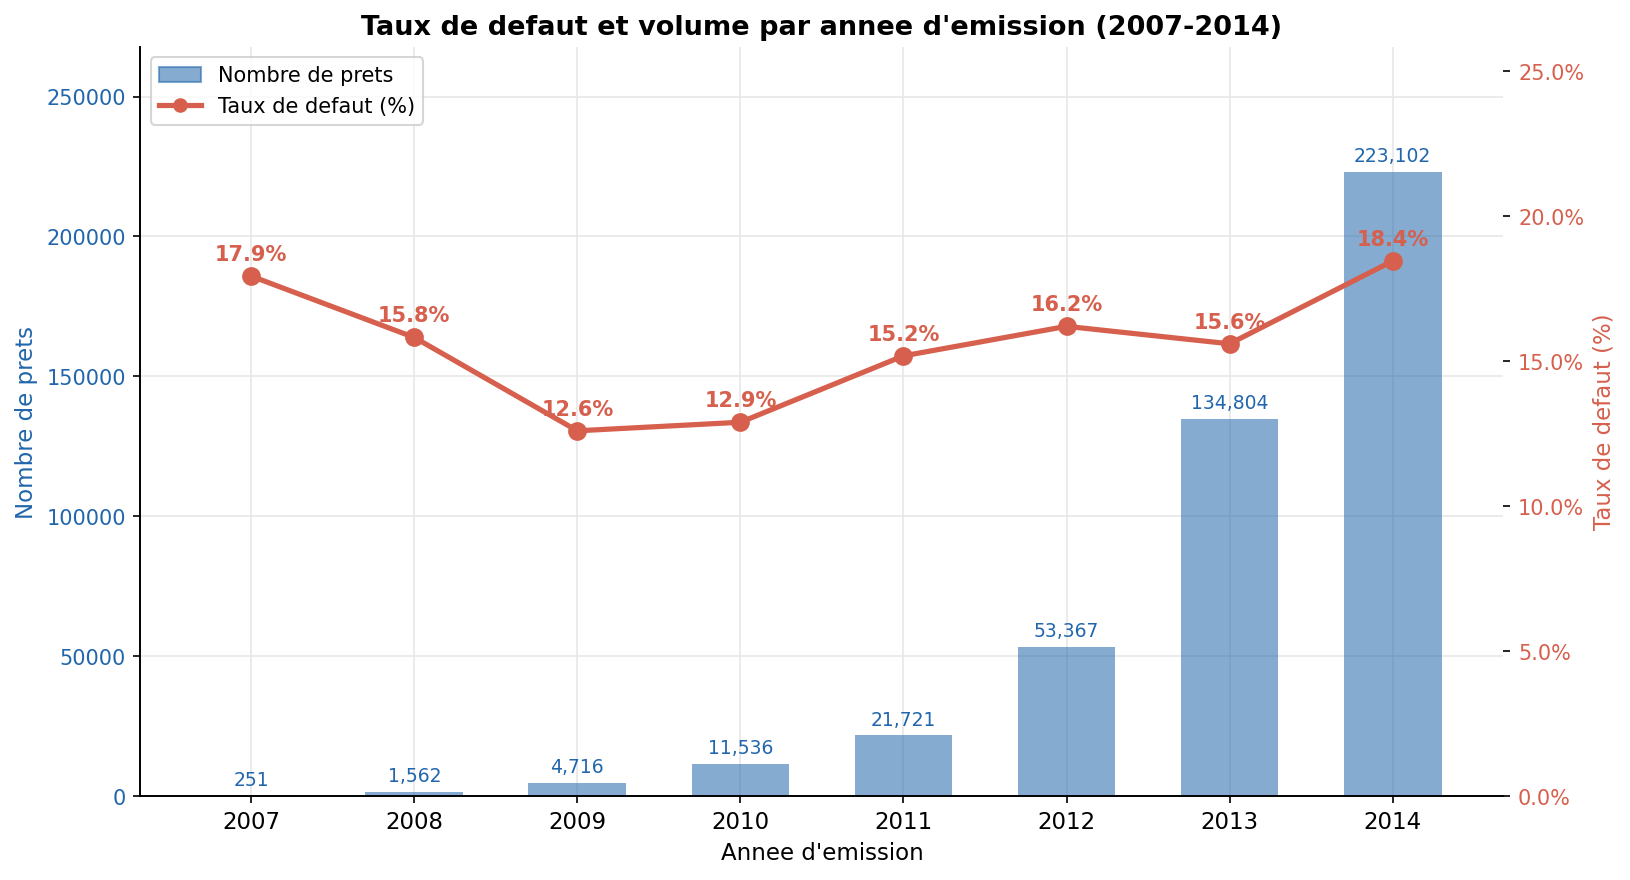

In [19]:
if 'issue_year' in data.columns:
    yearly = data.groupby('issue_year')['target'].agg(taux_defaut='mean',nb_prets='count').reset_index()
    yearly['taux_defaut_pct'] = yearly['taux_defaut'] * 100

    fig, ax_bar = plt.subplots(figsize=(11, 6))
    x = np.arange(len(yearly))
    bars = ax_bar.bar(x, yearly['nb_prets'], color=BLUE, alpha=0.55, width=0.6, zorder=2)
    for bar, val in zip(bars, yearly['nb_prets']):
        ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+yearly['nb_prets'].max()*0.01,
                    f"{val:,}", ha='center', va='bottom', fontsize=9, color=BLUE)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(yearly['issue_year'].astype(int), fontsize=11)
    ax_bar.set_ylabel('Nombre de prets', fontsize=11, color=BLUE)
    ax_bar.tick_params(axis='y', labelcolor=BLUE)
    ax_bar.set_ylim(0, yearly['nb_prets'].max()*1.2)

    ax_line = ax_bar.twinx()
    ax_line.plot(x, yearly['taux_defaut_pct'], color=RED, marker='o',
                 markersize=8, linewidth=2.5, zorder=5)
    for xi, val in zip(x, yearly['taux_defaut_pct']):
        ax_line.text(xi, val+0.4, f"{val:.1f}%", ha='center', va='bottom',
                     fontsize=10, fontweight='bold', color=RED, zorder=6)
    ax_line.set_ylabel('Taux de defaut (%)', fontsize=11, color=RED)
    ax_line.tick_params(axis='y', labelcolor=RED)
    ax_line.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_line.set_ylim(0, yearly['taux_defaut_pct'].max()*1.4)
    ax_line.grid(False)

    h1 = mpatches.Patch(color=BLUE, alpha=0.55, label='Nombre de prets')
    h2 = plt.Line2D([0],[0], color=RED, marker='o', lw=2.5, label='Taux de defaut (%)')
    ax_bar.legend(handles=[h1,h2], loc='upper left', fontsize=10)
    ax_bar.set_title("Taux de defaut et volume par annee d'emission (2007-2014)")
    ax_bar.set_xlabel("Annee d'emission", fontsize=11)
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.savefig('00_default_by_year.png', bbox_inches='tight', facecolor='white')
    plt.show()
    data.drop(columns=['issue_year'], inplace=True, errors='ignore')

> **Observation** : Le taux de défaut est particulièrement élevé pour les prêts de **2007–2008** (crise des subprimes). Le volume de prêts explose à partir de **2012**, témoignant de la montée en puissance de la plateforme Lending Club.

### 10.2 Répartition de la variable cible

**Q** : Le dataset est-il déséquilibré entre Fully Paid et Charged Off ?

**C** : Pie chart et barplot annotés.

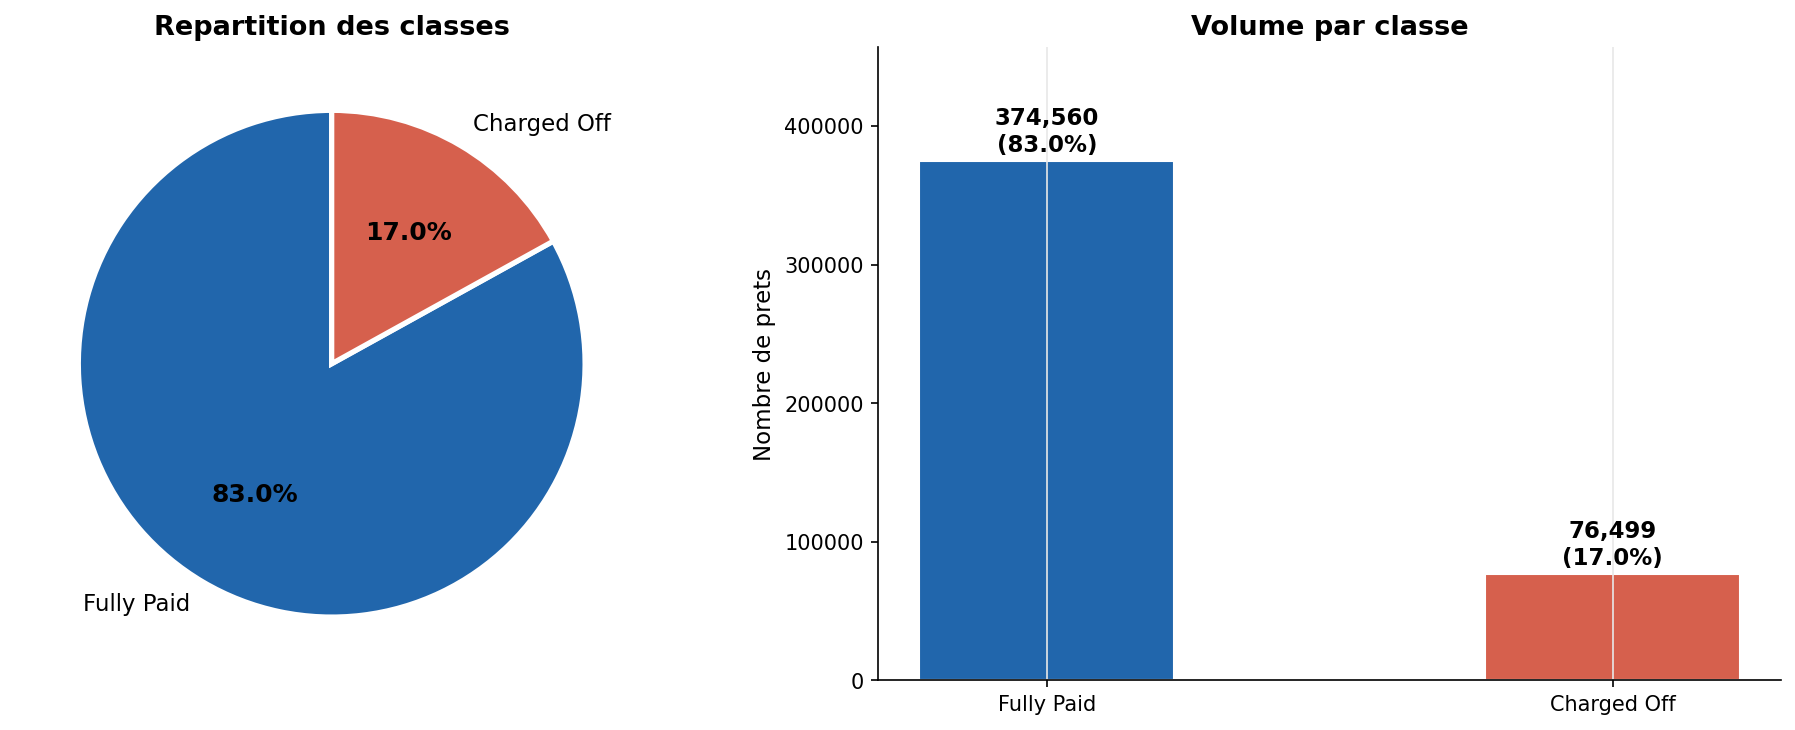

In [20]:
counts = data['target'].value_counts().sort_index()
labels = ['Fully Paid', 'Charged Off']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

wedges, texts, autotexts = axes[0].pie(
    counts, labels=labels, autopct='%1.1f%%', colors=[BLUE, RED],
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2.5),
    textprops=dict(fontsize=11))
for at in autotexts: at.set_fontweight('bold'); at.set_fontsize(12)
axes[0].set_title('Repartition des classes')

bars = axes[1].bar(labels, counts.values, color=[BLUE,RED], edgecolor='white', width=0.45)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+counts.max()*0.01,
                 f"{val:,}\n({val/counts.sum()*100:.1f}%)",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, counts.max()*1.22)
axes[1].set_ylabel('Nombre de prets')
axes[1].set_title('Volume par classe')
axes[1].grid(axis='y')
plt.tight_layout()
plt.savefig('02_target_distribution.png', bbox_inches='tight', facecolor='white')
plt.show()

> **Observation** : Le dataset est **fortement déséquilibré** — les Fully Paid représentent environ 80% des prêts. Ce déséquilibre sera compensé lors de la modélisation via `class_weight='balanced'` ou `scale_pos_weight`.

### 10.3 Distributions des variables numériques

**Q** : Les distributions diffèrent-elles entre Fully Paid et Charged Off ?

**C** : Courbes KDE normalisées avec médianes annotées. Le cap au 98e percentile évite que les outliers écrasent la visualisation.

In [ ]:
num_vars = [v for v in ['loan_amnt','annual_inc','dti','fico_range_low',
                         'revol_util','open_acc','installment','delinq_2yrs']
            if v in data.columns]

ncols = 4
nrows = -(-len(num_vars) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*4.5))
axes = axes.flatten()
d0_all = data[data['target']==0]
d1_all = data[data['target']==1]

for i, col in enumerate(num_vars):
    ax   = axes[i]
    d0   = d0_all[col].dropna()
    d1   = d1_all[col].dropna()
    cap  = data[col].quantile(0.98)
    d0, d1 = d0[d0<=cap], d1[d1<=cap]

    # KDE Fully Paid vs Charged Off
    sns.kdeplot(d0, ax=ax, color=BLUE, lw=2.5, label='Fully Paid')
    sns.kdeplot(d1, ax=ax, color=RED,  lw=2.5, linestyle='--', label='Charged Off')

    # Médianes
    ax.axvline(d0.median(), color=BLUE, lw=1.2, linestyle=':',
               label=f'Med.FP: {d0.median():.0f}')
    ax.axvline(d1.median(), color=RED,  lw=1.2, linestyle=':',
               label=f'Med.CO: {d1.median():.0f}')
    ax.set_title(col); ax.set_ylabel('Densité', fontsize=9)
    ax.legend(fontsize=7.5)

for j in range(len(num_vars), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distributions — Fully Paid vs Charged Off', fontsize=15)
plt.tight_layout()
plt.savefig('03_numeric_distributions.png', bbox_inches='tight')
plt.show()


> **Observation** : Le **score FICO** et le **DTI** montrent les écarts les plus marqués. Les emprunteurs en défaut ont un score FICO médian plus bas et un DTI plus élevé — cohérent avec le risque de crédit. Le montant du prêt (`loan_amnt`) présente une différence plus modérée.

### 10.4 Taux de défaut par variables catégorielles

**Q** : Certaines catégories présentent-elles un risque significativement plus élevé ?

**C** : Pour chaque variable, taux de défaut par modalité comparé à la moyenne globale (pointillé noir). Rouge = au-dessus de la moyenne, Bleu = en dessous.

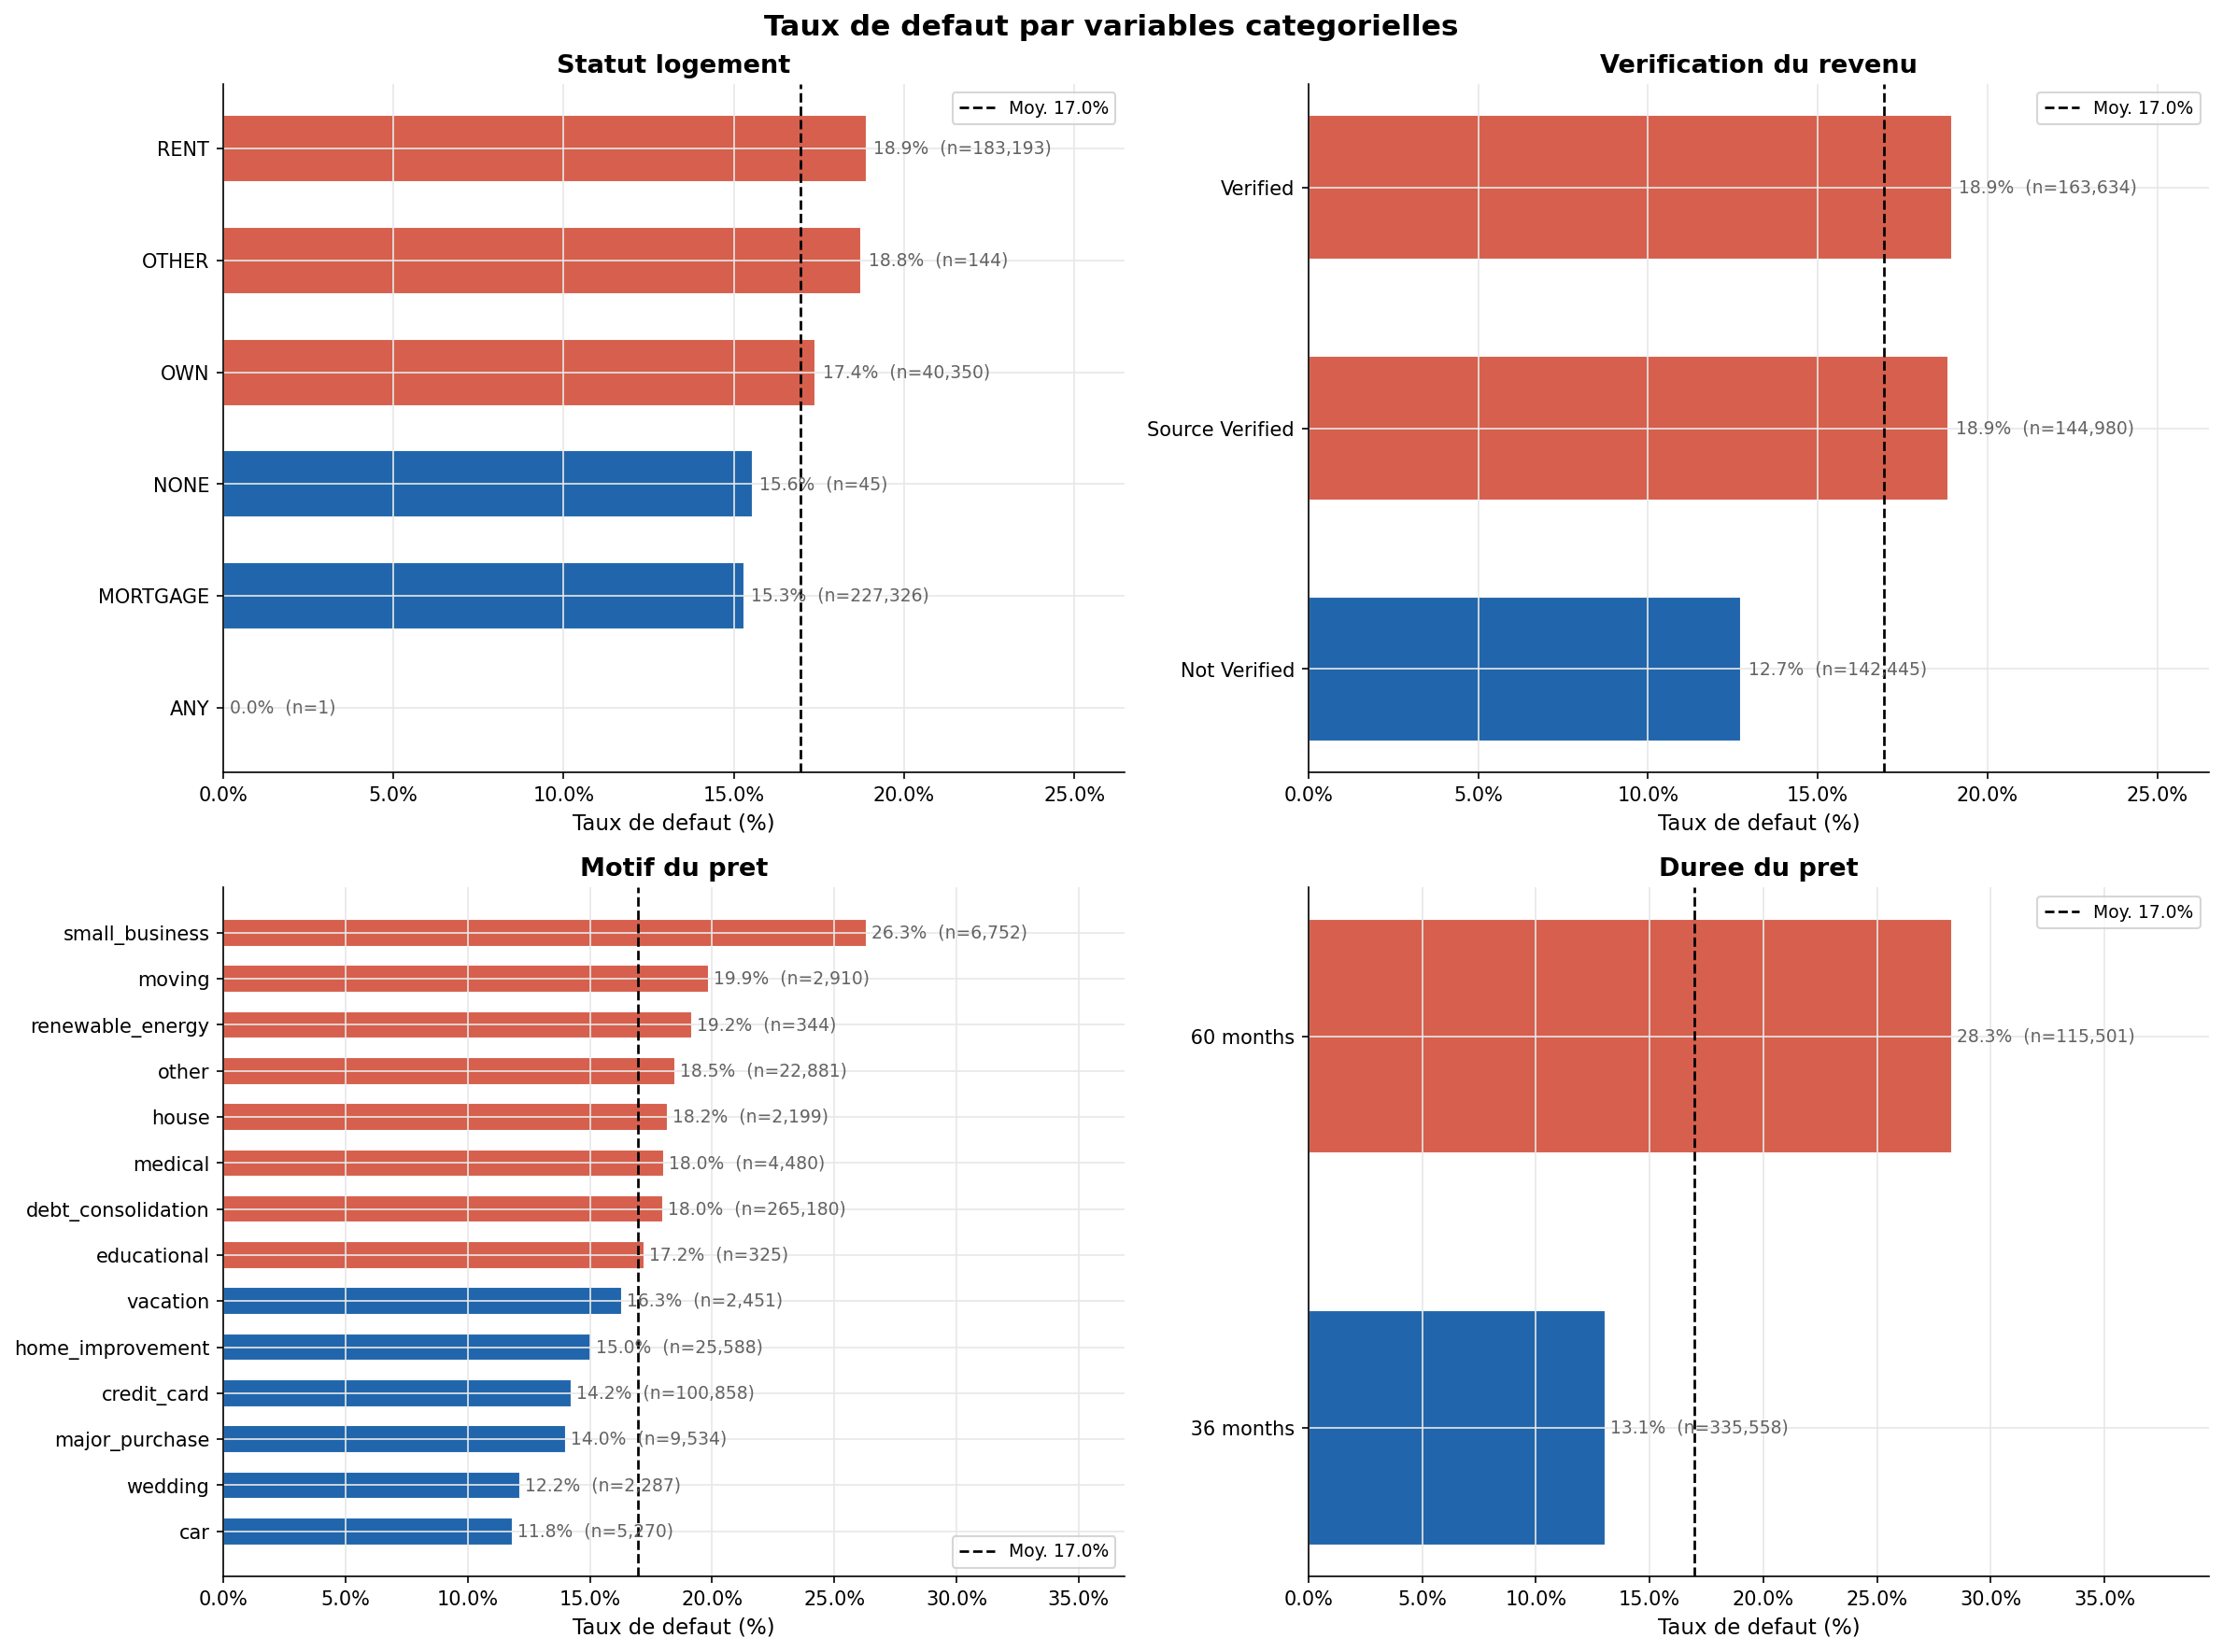

In [22]:
cat_eda = {k: v for k, v in {
    'home_ownership':      'Statut logement',
    'verification_status': 'Verification du revenu',
    'purpose':             'Motif du pret',
    'term':                'Duree du pret',
}.items() if k in data.columns}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('white')
axes = axes.flatten()

for i, (col, title) in enumerate(cat_eda.items()):
    ax = axes[i]
    agg = data.groupby(col)['target'].agg(dr='mean',n='count').reset_index().sort_values('dr')
    agg['dr_pct'] = agg['dr'] * 100
    bar_colors = [RED if v > global_rate else BLUE for v in agg['dr_pct']]
    bars = ax.barh(agg[col].astype(str), agg['dr_pct'],
                   color=bar_colors, edgecolor='white', height=0.6)
    for bar, row in zip(bars, agg.itertuples()):
        ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                f"{row.dr_pct:.1f}%  (n={row.n:,})", va='center', fontsize=9, color=GRAY)
    ax.axvline(global_rate, color='black', linestyle='--',
               lw=1.3, label=f'Moy. {global_rate:.1f}%')
    ax.set_xlim(0, agg['dr_pct'].max()*1.4)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(title); ax.set_xlabel('Taux de defaut (%)')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Taux de defaut par variables categorielles', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('04_categorical_default_rates.png', bbox_inches='tight', facecolor='white')
plt.show()

> **Observation** : Les prêts sur **60 mois** affichent un taux de défaut nettement supérieur aux prêts sur 36 mois. Les prêts pour **small_business** sont les plus risqués. Les revenus **non vérifiés** présentent paradoxalement un taux légèrement plus bas — probablement un biais de sélection (les emprunteurs sûrs d'eux ne demandent pas la vérification).

### 10.5 Boxplots — Variables numériques vs statut

**Q** : Les distributions des variables clés diffèrent-elles visuellement ?

**C** : Boxplots avec outliers cappés au 99e percentile. La médiane est annotée en blanc.

In [ ]:
box_vars = [v for v in ['loan_amnt','dti','annual_inc','fico_range_low','revol_util']
            if v in data.columns]

fig, axes = plt.subplots(1, len(box_vars), figsize=(18, 6))

for i, col in enumerate(box_vars):
    ax     = axes[i]
    df_box = data[[col,'target']].dropna()
    cap    = df_box[col].quantile(0.99)
    df_box = df_box[df_box[col] <= cap]

    # Palette : BLUE = Fully Paid, RED = Charged Off
    # Les clés doivent être des strings — seaborn convertit x en str
    sns.boxplot(x='target', y=col, data=df_box, ax=ax,
                palette={'0': BLUE, '1': RED},
                flierprops=dict(marker='.', markersize=2, alpha=0.25))

    # Annotation médiane
    for j, grp in enumerate([0, 1]):
        med = df_box[df_box['target']==grp][col].median()
        ax.text(j, med, f'{med:,.0f}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color='white')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Fully\nPaid', 'Charged\nOff'])
    ax.set_title(col)
    ax.set_xlabel('')

h1 = mpatches.Patch(color=BLUE, label='Fully Paid')
h2 = mpatches.Patch(color=RED,  label='Charged Off')
fig.legend(handles=[h1, h2], loc='upper center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Boxplots — Variables numériques vs statut du prêt', fontsize=15, y=1.06)
plt.tight_layout()
plt.savefig('06_boxplots_vs_target.png', bbox_inches='tight')
plt.show()


> **Observation** : Le **score FICO** est clairement plus élevé pour les Fully Paid. Le **DTI** est légèrement plus élevé pour les Charged Off. Le montant du prêt présente une différence modérée mais visible.

### 10.6 Score FICO et taux de défaut

**Q** : Le score FICO est-il un bon prédicteur du défaut ?

**C** : Taux de défaut par tranche FICO avec dégradé Rouge→Bleu (rouge = risque élevé, bleu = risque faible).

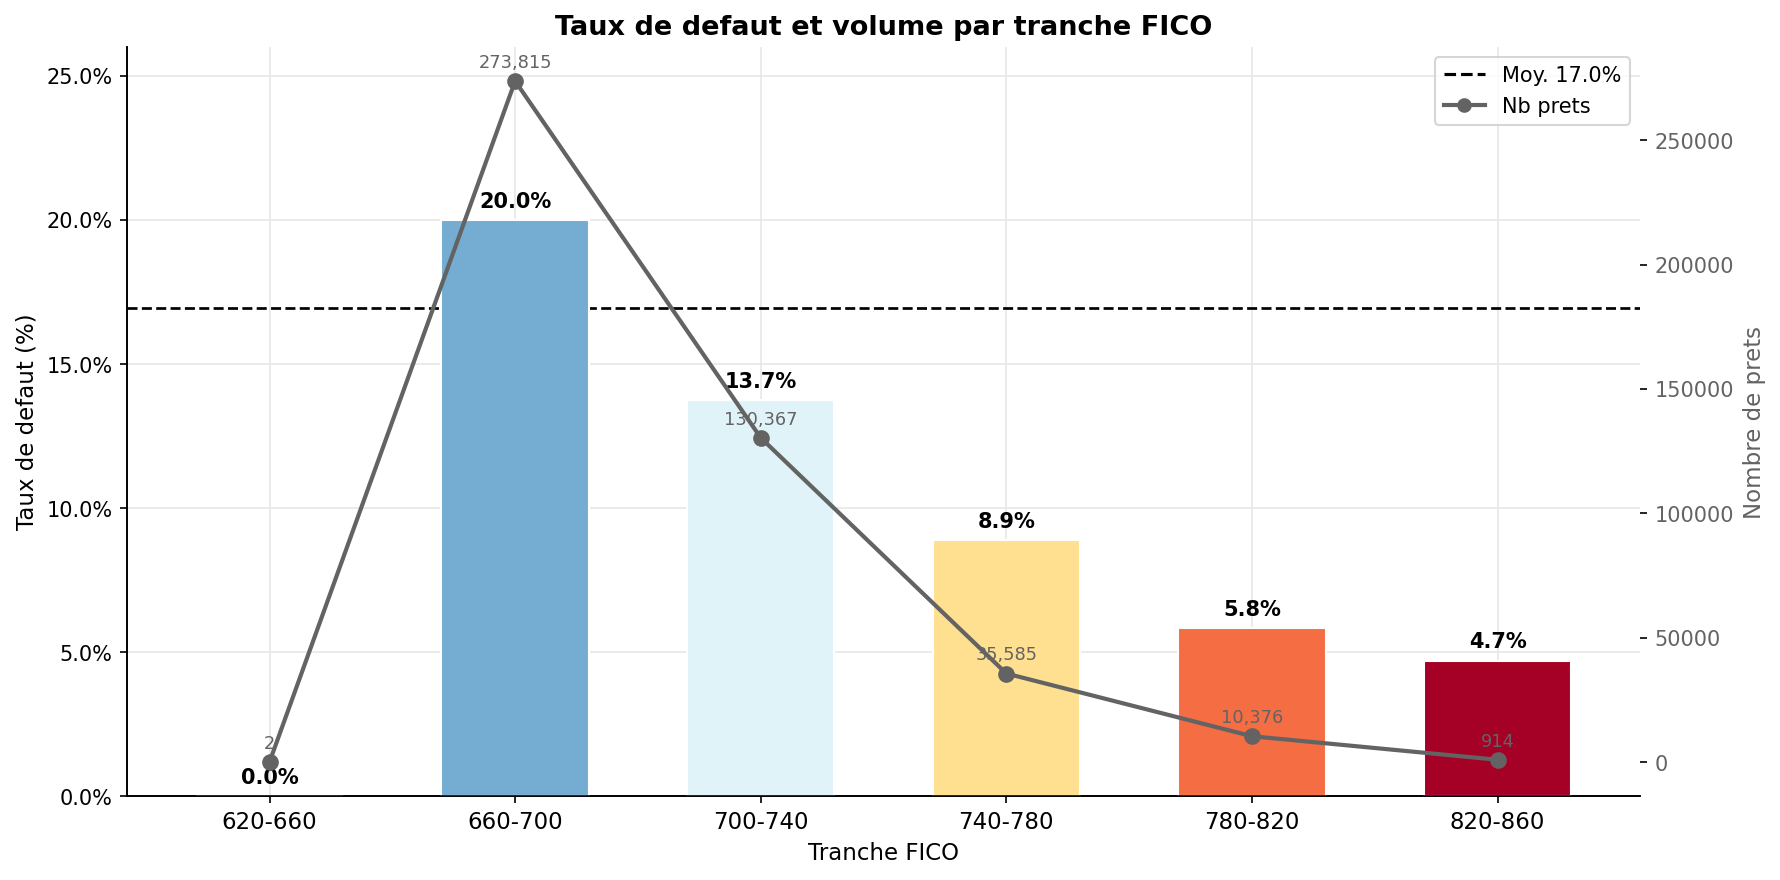

In [24]:
if 'fico_range_low' in data.columns and 'fico_range_high' in data.columns:
    data['fico_mid'] = (data['fico_range_low']+data['fico_range_high'])/2
    data['fico_bucket'] = pd.cut(data['fico_mid'],
        bins=[580,620,660,700,740,780,820,860],
        labels=['580-620','620-660','660-700','700-740','740-780','780-820','820-860'])
    fico_agg = data.groupby('fico_bucket',observed=True)['target'].agg(dr='mean',n='count').reset_index()
    fico_agg['dr_pct'] = fico_agg['dr']*100
    n_b = len(fico_agg)
    palette = [plt.cm.RdYlBu(i/(n_b-1)) for i in range(n_b-1,-1,-1)]

    fig, ax1 = plt.subplots(figsize=(12,6))
    fig.patch.set_facecolor('white')
    bars = ax1.bar(range(n_b), fico_agg['dr_pct'], color=palette, edgecolor='white', width=0.6, zorder=3)
    for bar, val in zip(bars, fico_agg['dr_pct']):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{val:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax2 = ax1.twinx()
    ax2.plot(range(n_b), fico_agg['n'], color=GRAY, marker='o', lw=2, markersize=7, zorder=4)
    for xi, val in enumerate(fico_agg['n']):
        ax2.text(xi, val+fico_agg['n'].max()*0.02, f"{val:,}", ha='center', fontsize=8.5, color=GRAY)
    ax2.set_ylabel('Nombre de prets', fontsize=11, color=GRAY)
    ax2.tick_params(axis='y', labelcolor=GRAY); ax2.grid(False)
    ax1.axhline(global_rate, color='black', linestyle='--',
                lw=1.3, label=f'Moy. {global_rate:.1f}%')
    ax1.set_xticks(range(n_b))
    ax1.set_xticklabels(fico_agg['fico_bucket'].astype(str), fontsize=11)
    ax1.set_xlabel('Tranche FICO', fontsize=11)
    ax1.set_ylabel('Taux de defaut (%)', fontsize=11)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax1.set_ylim(0, fico_agg['dr_pct'].max()*1.3)
    ax1.set_title('Taux de defaut et volume par tranche FICO')
    ax1.spines[['top','right']].set_visible(False)
    h1 = plt.Line2D([0],[0], color='black', linestyle='--', label=f'Moy. {global_rate:.1f}%')
    h2 = plt.Line2D([0],[0], color=GRAY, marker='o', lw=2, label='Nb prets')
    ax1.legend(handles=[h1,h2], fontsize=10, loc='upper right')
    plt.tight_layout()
    plt.savefig('08_fico_vs_default.png', bbox_inches='tight', facecolor='white')
    plt.show()
    data.drop(columns=['fico_mid','fico_bucket'], inplace=True)

> **Observation** : La relation est **clairement monotone décroissante** — plus le score FICO est élevé, moins le risque de défaut est important. Les emprunteurs avec un score inférieur à **660** présentent un taux bien au-dessus de la moyenne globale. C'est l'une des variables les plus discriminantes du dataset.

### 10.7 Ancienneté professionnelle

**Q** : L'ancienneté professionnelle influence-t-elle le risque de défaut ?

**C** : Barplot du taux de défaut par tranche d'ancienneté.

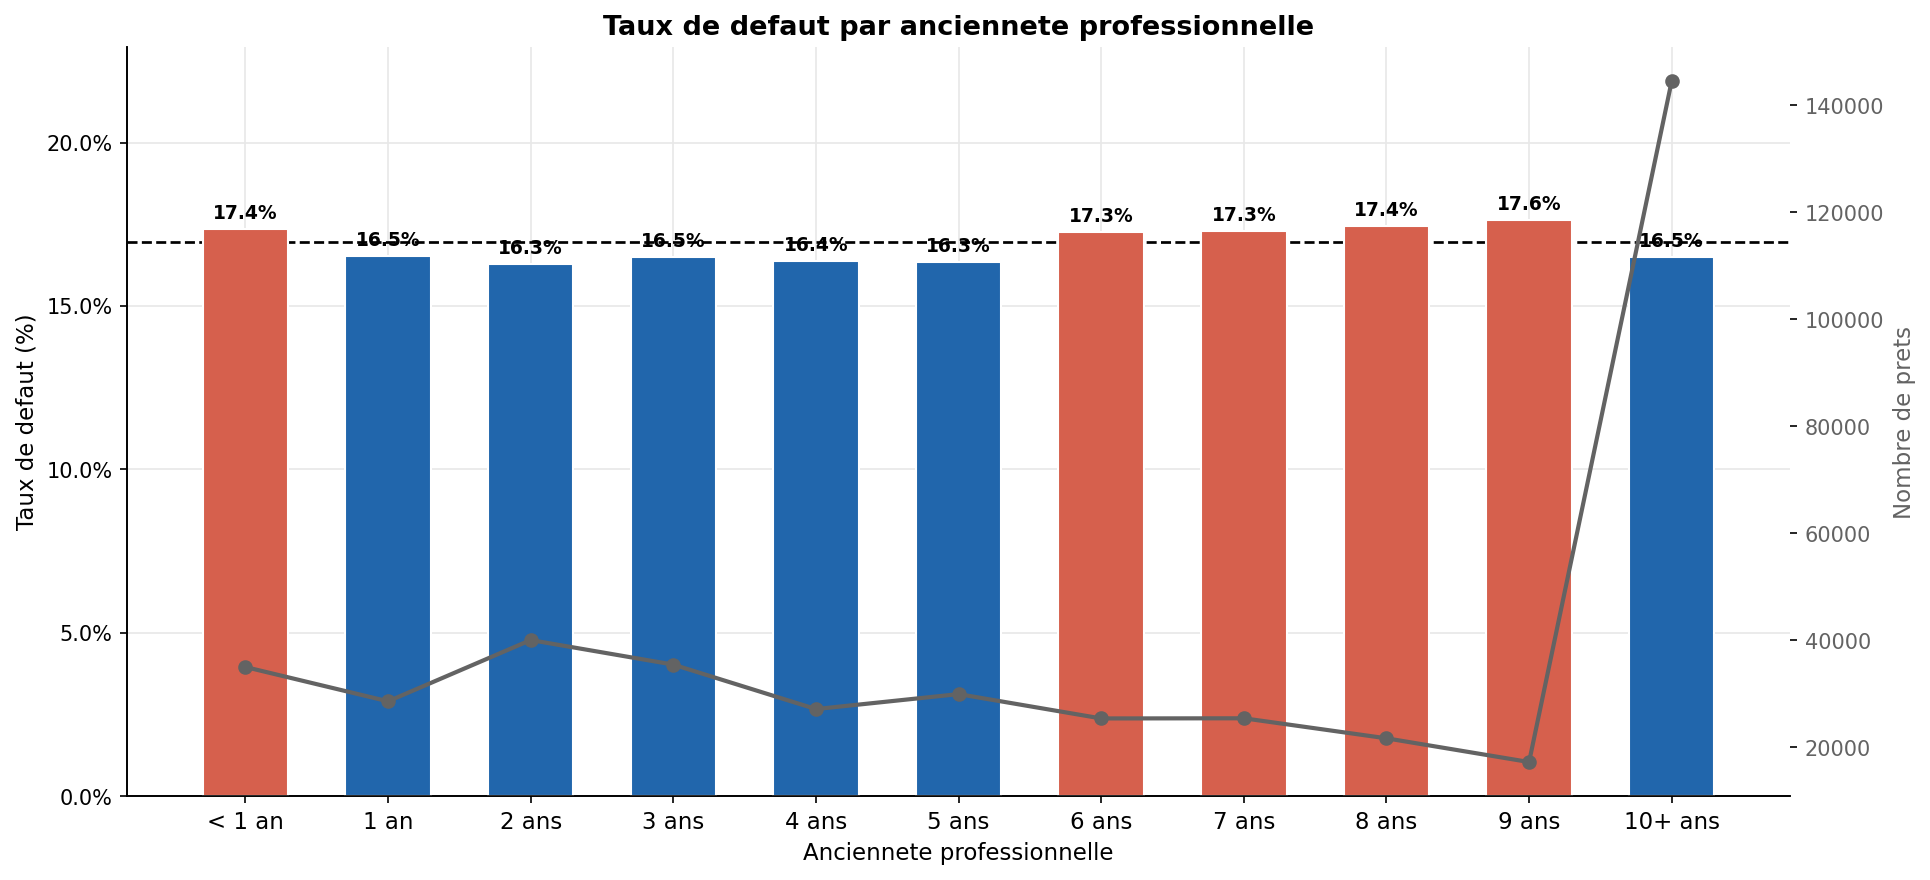

In [25]:
if 'emp_length' in data.columns:
    emp_labels = {0:'< 1 an',1:'1 an',2:'2 ans',3:'3 ans',4:'4 ans',5:'5 ans',
                  6:'6 ans',7:'7 ans',8:'8 ans',9:'9 ans',10:'10+ ans'}
    data['emp_label'] = data['emp_length'].map(emp_labels)
    emp_order = list(emp_labels.values())
    emp_agg = data.groupby('emp_label')['target'].agg(dr='mean',n='count').reset_index()
    emp_agg['dr_pct'] = emp_agg['dr']*100
    emp_agg['order'] = emp_agg['emp_label'].map({v:i for i,v in enumerate(emp_order)})
    emp_agg = emp_agg.dropna(subset=['order']).sort_values('order')

    fig, ax1 = plt.subplots(figsize=(13,6))
    fig.patch.set_facecolor('white')
    ax2 = ax1.twinx()
    x = np.arange(len(emp_agg))
    bar_colors = [RED if v > global_rate else BLUE for v in emp_agg['dr_pct']]
    bars = ax1.bar(x, emp_agg['dr_pct'], color=bar_colors, edgecolor='white', width=0.6, zorder=3)
    for bar, val in zip(bars, emp_agg['dr_pct']):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f"{val:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.plot(x, emp_agg['n'], color=GRAY, marker='o', lw=2, markersize=6, zorder=4)
    ax2.set_ylabel('Nombre de prets', fontsize=11, color=GRAY)
    ax2.tick_params(axis='y', labelcolor=GRAY); ax2.grid(False)
    ax1.axhline(global_rate, color='black', linestyle='--', lw=1.3)
    ax1.set_xticks(x); ax1.set_xticklabels(emp_agg['emp_label'], fontsize=11)
    ax1.set_xlabel('Anciennete professionnelle', fontsize=11)
    ax1.set_ylabel('Taux de defaut (%)', fontsize=11)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax1.set_ylim(0, emp_agg['dr_pct'].max()*1.3)
    ax1.set_title('Taux de defaut par anciennete professionnelle')
    ax1.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('09_emp_length_vs_default.png', bbox_inches='tight', facecolor='white')
    plt.show()
    data.drop(columns=['emp_label'], inplace=True)

> **Observation** : Le taux de défaut est légèrement plus élevé pour les emprunteurs avec moins d'1 an d'ancienneté. Les 10+ ans représentent le groupe le plus important et affichent un risque proche de la moyenne — ce qui suggère que l'ancienneté seule est un signal faible, à combiner avec d'autres variables.

### 10.8 Analyse par région géographique

**Q** : Existe-t-il des disparités régionales dans le risque de défaut ?

**C** : Les 50 états sont regroupés en 4 régions. Barplot du taux de défaut + pie chart de la répartition du volume.

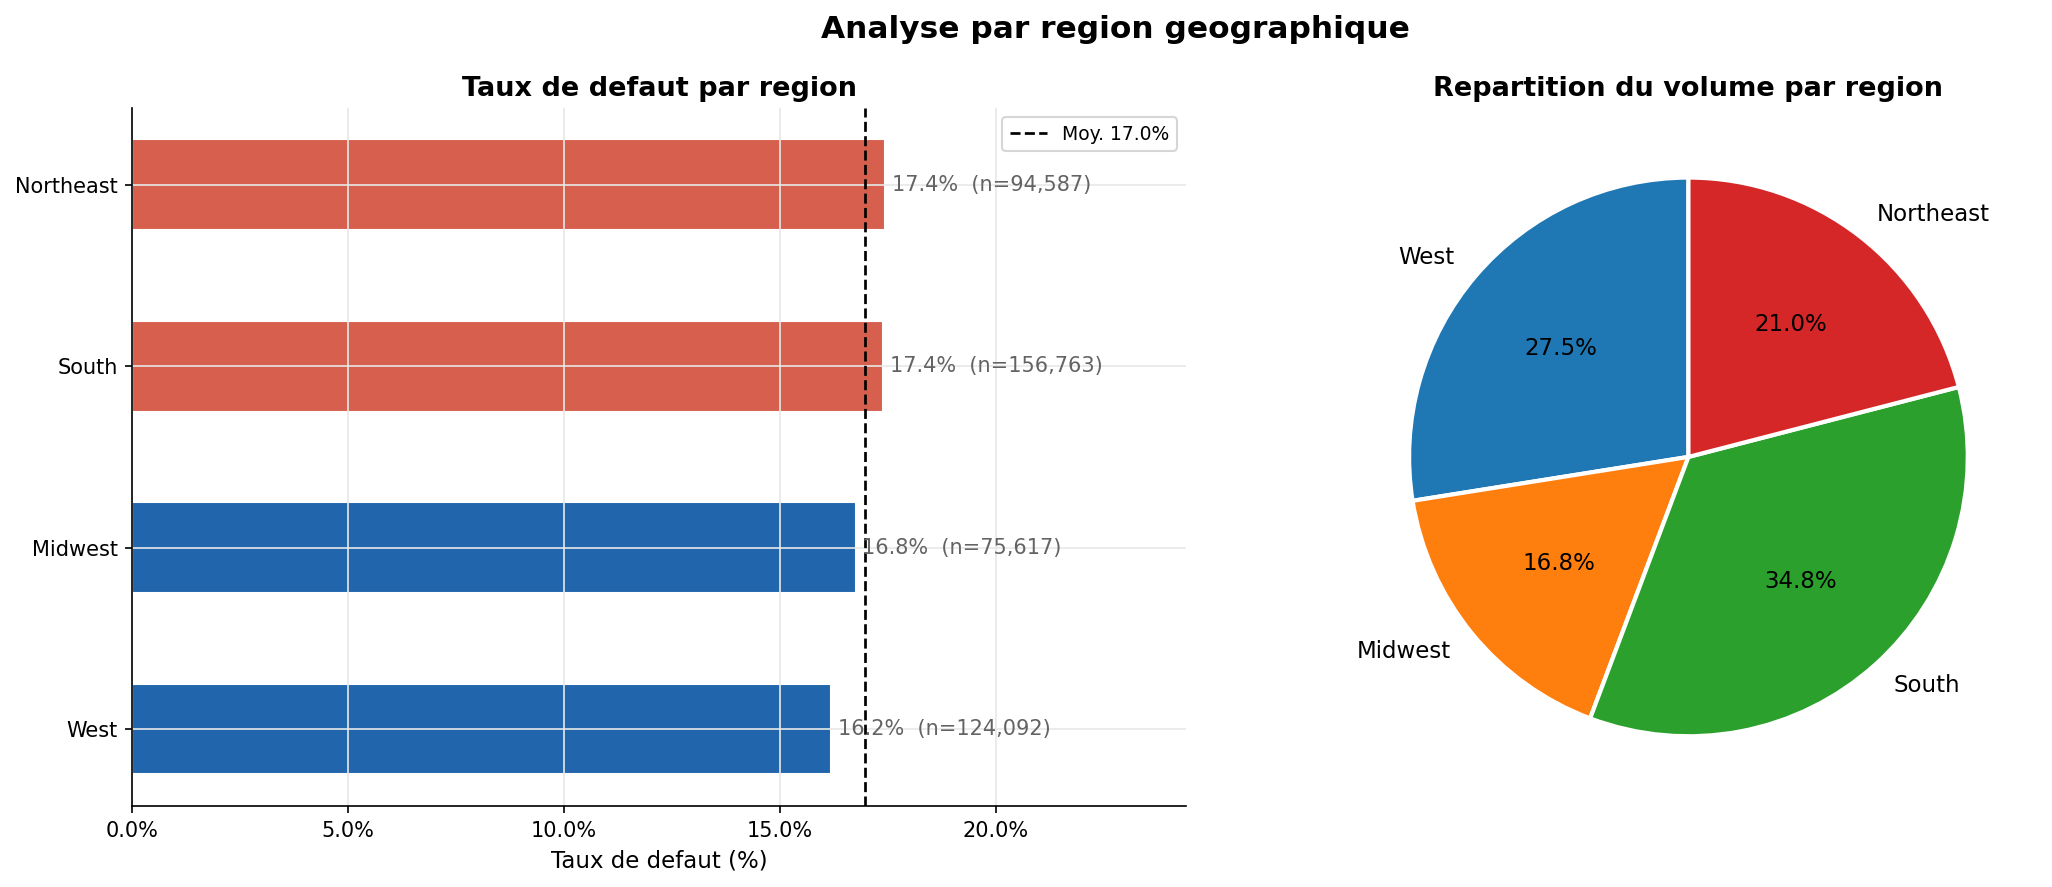

In [26]:
if 'region' in data.columns:
    region_agg = data.groupby('region')['target'].agg(dr='mean',n='count').reset_index().sort_values('dr')
    region_agg['dr_pct'] = region_agg['dr']*100

    fig, axes = plt.subplots(1, 2, figsize=(15,6))
    fig.patch.set_facecolor('white')
    bar_colors = [RED if v > global_rate else BLUE for v in region_agg['dr_pct']]
    bars = axes[0].barh(region_agg['region'], region_agg['dr_pct'],
                        color=bar_colors, edgecolor='white', height=0.5)
    for bar, row in zip(bars, region_agg.itertuples()):
        axes[0].text(bar.get_width()+0.15, bar.get_y()+bar.get_height()/2,
                     f"{row.dr_pct:.1f}%  (n={row.n:,})", va='center', fontsize=10, color=GRAY)
    axes[0].axvline(global_rate, color='black', linestyle='--',
                    lw=1.3, label=f'Moy. {global_rate:.1f}%')
    axes[0].set_xlim(0, region_agg['dr_pct'].max()*1.4)
    axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
    axes[0].set_title('Taux de defaut par region')
    axes[0].set_xlabel('Taux de defaut (%)')
    axes[0].legend(fontsize=9)
    axes[0].spines[['top','right']].set_visible(False)
    axes[1].pie(region_agg['n'], labels=region_agg['region'], autopct='%1.1f%%',
                startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
                textprops=dict(fontsize=11))
    axes[1].set_title('Repartition du volume par region')
    fig.suptitle('Analyse par region geographique', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('10_region_vs_default.png', bbox_inches='tight', facecolor='white')
    plt.show()

> **Observation** : Les disparités régionales sont modérées. La région **South** tend à présenter un taux légèrement plus élevé. La région **West** concentre le plus grand volume de prêts (California notamment). Ces différences peuvent refléter des réalités économiques locales.

### 10.9 Matrice de corrélation

**Q** : Existe-t-il des corrélations fortes entre variables numériques ?

**C** : Heatmap triangulaire inférieure avec palette divergente centrée sur 0.

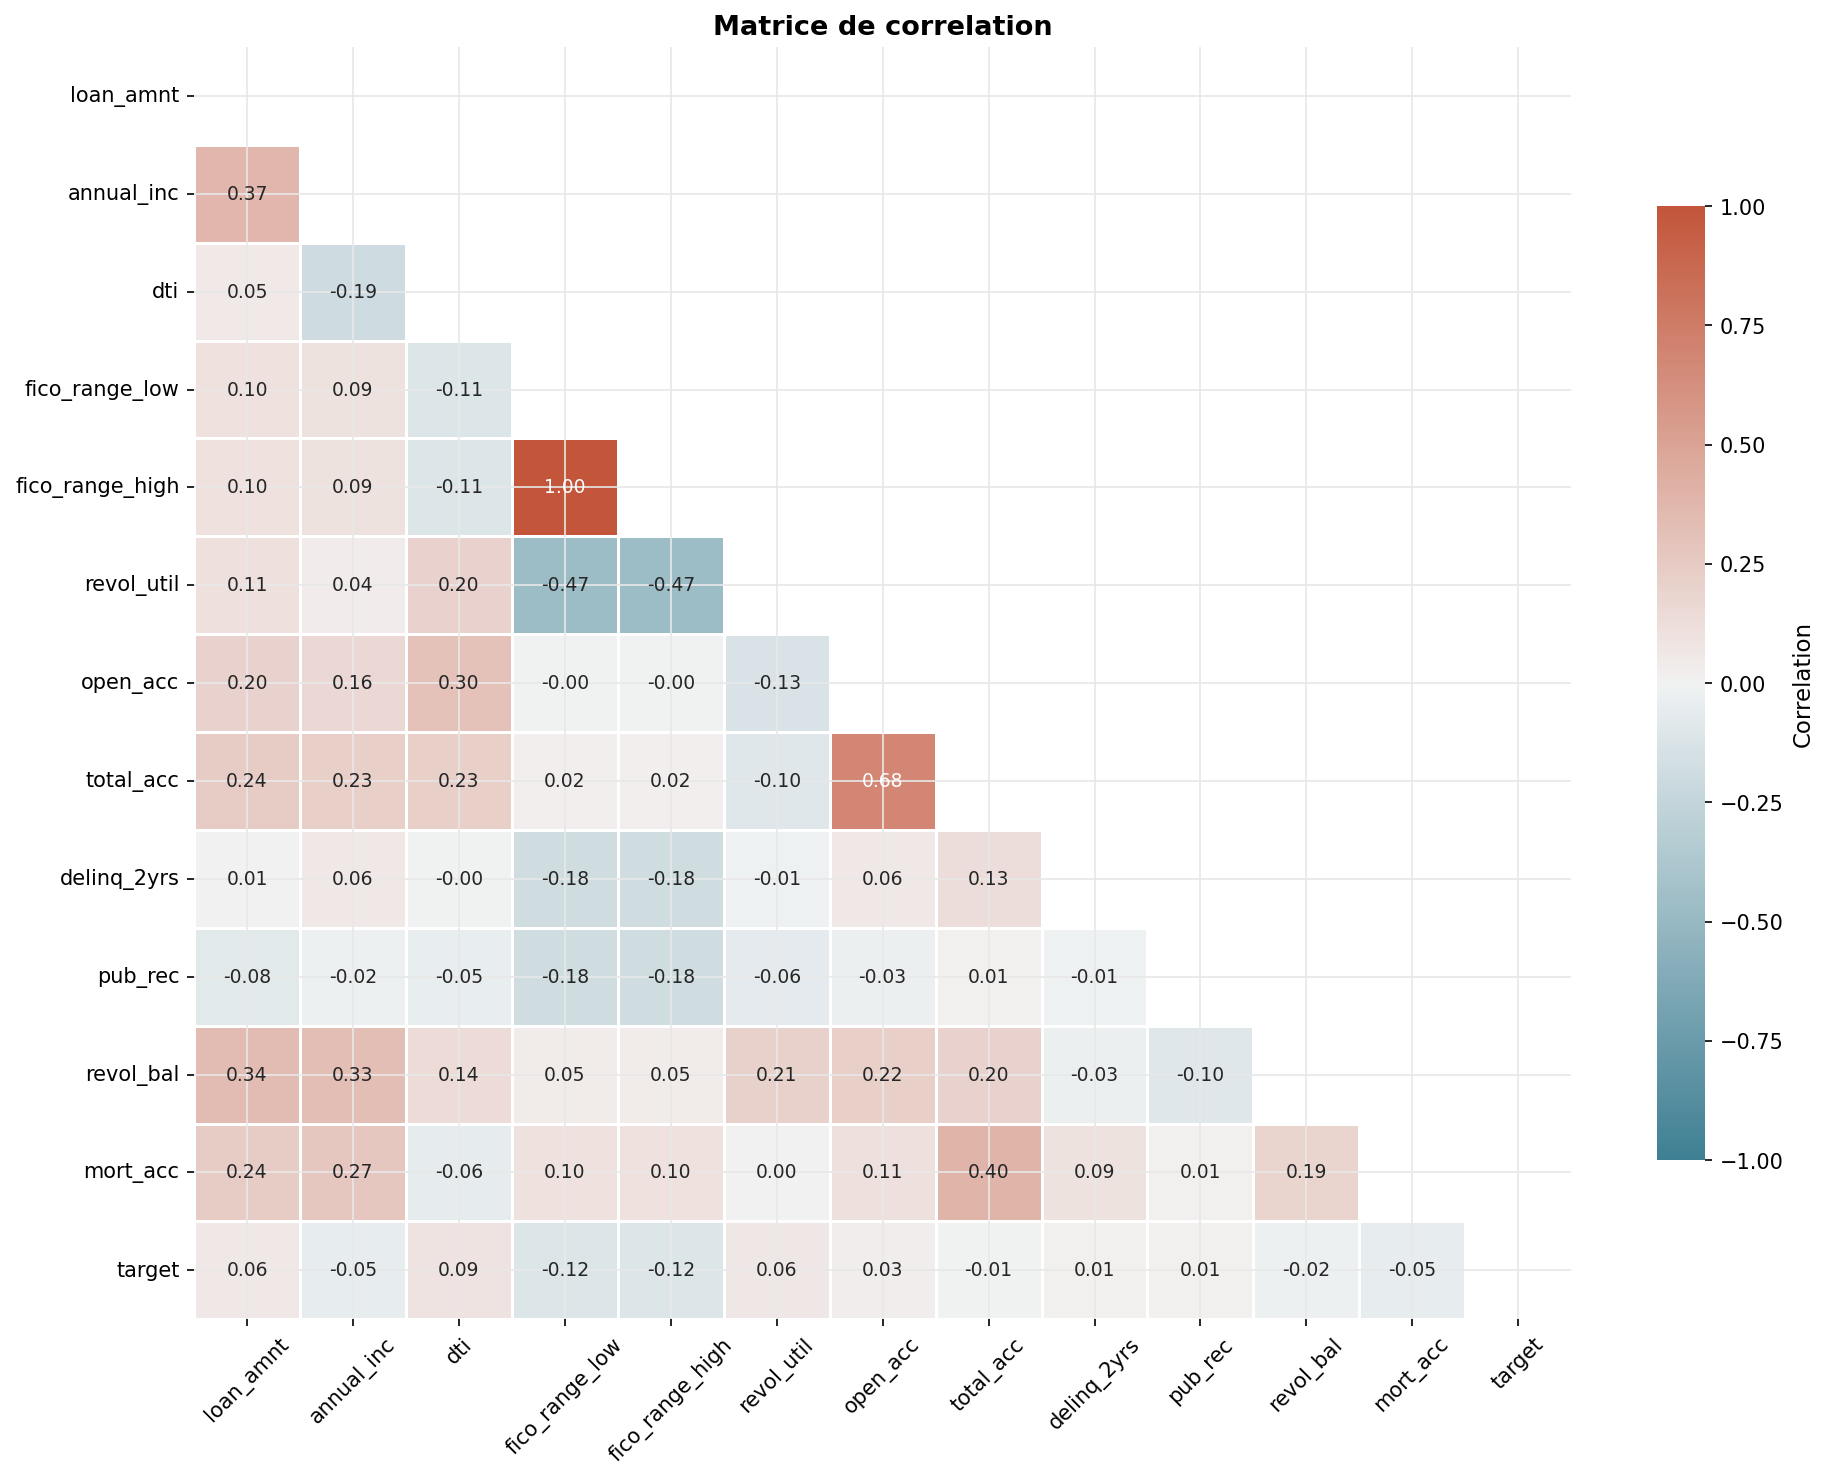

In [27]:
corr_vars = [c for c in ['loan_amnt','annual_inc','dti','fico_range_low','fico_range_high',
                          'revol_util','open_acc','total_acc','delinq_2yrs','pub_rec',
                          'revol_bal','mort_acc','target']
             if c in data.columns]
corr = data[corr_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13,10))
fig.patch.set_facecolor('white')
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(220,20,as_cmap=True),
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.6, linecolor='white',
            annot_kws={'size':9},
            cbar_kws={'shrink':0.75,'label':'Correlation'})
ax.set_title('Matrice de correlation')
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.savefig('07_correlation_matrix.png', bbox_inches='tight', facecolor='white')
plt.show()

> **Observation** : `fico_range_low` et `fico_range_high` sont quasi-identiques (corrélation ~1) — on n'en gardera qu'une. `loan_amnt` et `revol_bal` sont modérément corrélés à la cible. La plupart des corrélations entre prédicteurs restent faibles, ce qui est favorable pour les modèles.

---
## 11. Encodage des variables catégorielles

**Q** : Comment transformer les variables catégorielles en numériques pour la modélisation ?

**C** : `pd.get_dummies` (One-Hot Encoding). `drop_first=True` supprime la première modalité comme référence pour éviter la multicolinéarité (dummy trap).


In [ ]:
# Colonnes catégorielles restantes (hors colonnes de travail intermédiaires)
cat_cols = [c for c in data.select_dtypes(include='object').columns
            if c not in ['emp_label', 'fico_bucket']]

print('Variables catégorielles à encoder :')
for c in cat_cols:
    print(f'  {c:<30} {data[c].nunique():>3} modalités  '
          f'→ {data[c].nunique()-1:>3} colonnes créées (drop_first=True)')

print(f'\nDimensions avant encodage : {data.shape[0]:,} x {data.shape[1]}')

# Encodage One-Hot
data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True, dtype=int)

print(f'Dimensions après encodage  : {data_encoded.shape[0]:,} x {data_encoded.shape[1]}')
print(f'Nouvelles colonnes créées  : {data_encoded.shape[1] - data.shape[1]}')

# Vérification : plus aucune colonne object
remaining_obj = data_encoded.select_dtypes(include='object').columns.tolist()
print(f'Colonnes object restantes  : {remaining_obj if remaining_obj else "Aucune ✓"}')


In [ ]:
# Visualisation : nombre de colonnes créées par variable encodée
dummies_count = {c: len([col for col in data_encoded.columns if col.startswith(f'{c}_')])
                 for c in cat_cols}

fig, ax = plt.subplots(figsize=(9, max(3, len(cat_cols)*0.5)))
ax.barh(list(dummies_count.keys()), list(dummies_count.values()),
        color=BLUE, alpha=0.8, edgecolor='white')
for bar, val in zip(ax.patches, dummies_count.values()):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Nombre de colonnes binaires créées')
ax.set_title('Encodage One-Hot — colonnes créées par variable')
plt.tight_layout()
plt.savefig('12_encodage_dummies.png', bbox_inches='tight')
plt.show()

print(f'\nDataset final encodé : {data_encoded.shape[0]:,} lignes x {data_encoded.shape[1]} colonnes')
print('→ Prêt pour la modélisation (toutes les variables sont numériques)')


> **Observation** : Après encodage One-Hot, le dataset ne contient plus aucune variable catégorielle.
> Chaque modalité (sauf la référence) est représentée par une colonne binaire 0/1.
> `purpose` génère le plus de colonnes car elle a le plus grand nombre de modalités.
> Le dataset `data_encoded` est prêt pour la modélisation.


---
## 12. Résumé de l'EDA

| # | Analyse | Question | Décision |
|---|---------|----------|----------|
| 1 | Évolution temporelle | Crise 2007–2008 visible ? | Oui — taux défaut élevé, volume faible |
| 2 | Valeurs manquantes | Variables >50% NaN ? | Supprimées, reste → imputation médiane |
| 3 | Répartition classes | Déséquilibre ? | ~80/20 → class_weight à la modélisation |
| 4 | **Boxplots univariés** | Distributions individuelles ? | annual_inc, revol_bal très asymétriques |
| 5 | **Histogrammes + KDE** | Forme réelle des distributions ? | Plusieurs vars à queue longue (|skew|>1) |
| 6 | **Skewness** | Variables à transformer ? | Identifiées — log1p pour modèles linéaires |
| 7 | **Outliers** | Méthode retenue ? | Conservation brute (arbres) / log1p (linéaires) |
| 8 | KDE numériques bivariées | Distributions différentes ? | FICO et DTI : écarts les plus marqués |
| 9 | Catégorielles | Modalités à risque ? | Prêts 60 mois et small_business |
| 10 | Boxplots bivariés | Différences visuelles ? | FICO confirme son pouvoir discriminant |
| 11 | FICO par tranche | Relation monotone ? | Oui — claire et forte |
| 12 | emp_length | Impact ancienneté ? | Signal faible, à combiner |
| 13 | Région | Disparités géo ? | Modérées — South légèrement plus risqué |
| 14 | Corrélation | Redondances ? | fico_low/high quasi-identiques |
| 15 | **Encodage get_dummies** | Dataset prêt ? | ✓ Toutes variables numériques |

**→ Prochaine étape : Modélisation (XGBoost, Random Forest, Régression Logistique)**


In [ ]:
print(f'Dataset final encodé : {data_encoded.shape[0]:,} lignes x {data_encoded.shape[1]} colonnes')
print(f'Fully Paid  : {(data_encoded["target"]==0).sum():,}  '
      f'({(data_encoded["target"]==0).mean()*100:.1f}%)')
print(f'Charged Off : {(data_encoded["target"]==1).sum():,}  '
      f'({(data_encoded["target"]==1).mean()*100:.1f}%)')
